In [1]:
import os
from pathlib import Path
from subprocess import run

import matplotlib.pyplot as plt
import numpy as np
import ogstools as ot
import ogstools.variables as ov

import pyvista as pv
pv.set_jupyter_backend("static")  # no rotating/zooming in the notebook

# Local
from CubicDomainWithFault import CubicDomainWithFault

## Path

In [2]:
out_dir = Path("_out")
out_dir.mkdir(parents=True, exist_ok=True)

fig_dir = out_dir / "Figure"
fig_dir.mkdir(parents=True, exist_ok=True)

mesh_dir = Path(out_dir, "mesh")
mesh_dir.mkdir(parents=True, exist_ok=True)

#  Simulation liquid injection into rock fault 


## 1. Definitions

The purpose of this benchmark is to investigate the hydraulic mechanical (HM) processes in the near field of rock, where liquid injection takes place. The schematic of the simulation model is depicted in the following figure:

<figure align="center">
    <img src="Figure/schematic.png" alt="caption" width="480"/>
  <figcaption>Figure 1: Schematic view of the simulation model.</figcaption>
</figure>

### 1.1 Boundary conditions

The boundary conditions are given in the following table:

| Boundary             | Hydraulic condition        | Mechanical condition                                   |
|----------------------|----------------------------|--------------------------------------------------------|
| Left & front faces   | No liquid flux             | No normal displacement                                 |
| Right face           | No liquid flux             | Normal traction $\tau_x = -5.5$ MPa                     |
| Back face            | No liquid flux             | Normal traction $\tau_y = -2.6$ MPa                     |
| Top                  | $p_l = \rho_w g z$ MPa            | Normal traction $\tau_z = -3.6$ MPa                  |
| Bottom               | $p_l = \rho_w g z$ MPa            | No normal displacement                     |


### 1.2 Initial conditions
The initial conditions of temperature are liquid pressure are gradient from their top boundary condition value to their bottom boundary condition value, respectively. The initial total stress are $\sigma_{xx}=-5.5$ MPa,  $\sigma_{yy}=-2.6$ MPa,  and $\sigma_{zz}=-3.6$ MPa. The initial pressure is $\rho_w g z$. 

### 1.3 Material properties
The model or values of the liquid properties are given in the following table: 

| Property             | Value          | Unit      |
|----------------------|----------------------------|----------------------------|
| Density              | $1000.0(1.0+10^{-10}(p_l-10^5)$| $\text{kg}\cdot\text{m}^{-3}$|
| Viscosity  | $10^{-3}$ | $\text{Pa}\cdot\text{s}$|


The values of the rock matrix properties are given in the following table: 

| Property             | Value          | Unit      |
|----------------------|----------------------------|----------------------------|
| Density              | $2750.0$| $\text{kg}\cdot\text{m}^{-3}$|
| Biot's constant      | $0.6$| - |
| Porosity  | $0.001$ | -|
| Permeability  | $2\cdot 10^{-20}$ | $\text{m}^{2}$|
| Young's modulus  | $80$ | GPa|
| Poisson'ratio  | $0.21$ | -|

The values of the fault properties are given in the following table: 

| Property             | Value          | Unit      |
|----------------------|----------------------------|----------------------------|
| Density              | $2600.0$| $\text{kg}\cdot\text{m}^{-3}$|
| Biot's constant      | $0.6$| - |
| Porosity  | $0.1$ | -|
| Permeability  | $1\cdot 10^{-14}$ | $\text{m}^{2}$|
| Young's modulus  | $8.0$ | GPa|
| Poisson'ratio  | $0.25$ | -|

The injection well is represented as a vertical line starting from the fault center and ending at the top surface. The injection rate is given in the following figure:

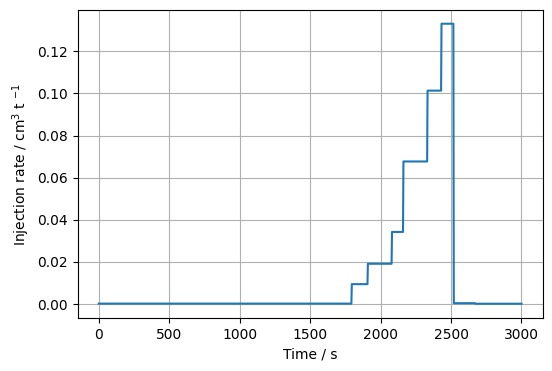

In [3]:
def q_in(t):
    return np.where(
        t < 1794.21,
        4.99798e-08,
        np.where(
            t < 1909.81,
            9.31177e-06,
            np.where(
                t < 2079.81,
                1.90107e-05,
                np.where(
                    t < 2160.01,
                    3.41504e-05,
                    np.where(
                        t < 2330.81,
                        6.7659e-05,
                        np.where(
                            t < 2430.41,
                            1.01353e-04,
                            np.where(
                                t < 2517.81,
                                1.33182e-04,
                                np.where(t < 2669.81, 2.52185e-07, 0.0),
                            ),
                        ),
                    ),
                ),
            ),
        ),
    )


t = np.linspace(0, 3000, 1000)

q_total = q_in(t) * 1000

plt.rcParams["figure.figsize"] = [6, 4]
plt.plot(t, q_total, color="C0")
plt.ylabel(r"Injection rate / cm$^3$ t $^{-1}$")
plt.xlabel("Time / s")
plt.grid(True)
plt.show()

## 2. Mesh generation

Since the material properties are homogeneous, and the model is symmetric to the vertical middle cross section of the fault, a half of the domain cutting by the symmetric plane, the vertical middle cross section of the fault, is used for the simulation. The geometry data are
- The height of the domain,  H, is 50 m.
- The wide of the domain, W, is 50 m.
- The thickness of the domain, T, is 49 m.
- Aperture of the fault is 1 m.
- The $z$ coordinate of the domain center is -300 m.

As shown in the following figure, the mesh has two material groups representing the rock mass, and the fault (in red color), respectively. The injection well is depicted in the mesh as well.
<figure align="center">
    <img src="Figure/mesh.png" alt="caption" width="320"/>
  <figcaption>Figure 2: Mesh.</figcaption>
</figure>

In [4]:
### %%capture
# Define domain parameters
wide = 50.0  # Width in x-direction (m)
height = 50.0  # Height in y-direction (m)
thickness = 50.0  # Thickness in z-direction (m)
z_center = -300  # Z-coordinate of domain center (m)
aperture = 0.5  # Aperture (thickness) of fault subdomain (m)

# Create the cubic domain with fault
domain = CubicDomainWithFault(wide, height, thickness, z_center, aperture)

# Print domain information
print("=" * 60)
print("CUBIC DOMAIN WITH FAULT SUBDOMAIN")
print("=" * 60)
print(f"Domain dimensions:")
print(f"  Width (X): {wide} m")
print(f"  Height (Y): {height} m")
print(f"  Thickness (Z): {thickness} m")
print(f"  Z-center: {z_center} m")
print(f"\nFault subdomain (vertical strip at back):")
print(f"  Aperture (thickness in Y): {aperture} m")
print(f"  X-range: [{domain.x_min:.2f}, {domain.x_max:.2f}] m")
print(f"  Y-range: [{domain.fault_y_min:.2f}, {domain.fault_y_max:.2f}] m")
print(f"  Z-range: [{domain.z_min:.2f}, {domain.z_max:.2f}] m")
print(f"\nVertical line inside fault:")
print(f"  Position: X = 0 m, Y = {domain.fault_y_max:.2f} m")
print(f"  Starts at Z = {domain.line_start_z:.2f} m (center of fault domain)")
print(f"  Ends at Z = {domain.line_end_z:.2f} m (top surface)")
print("=" * 60)

try:
    # Create geometry
    print("\nCreating geometry...")
    domain.create_geometry()

    # Assign physical groups
    print("\nAssigning physical groups...")
    domain.assign_physical_groups()

    # Generate mesh
    print("\nGenerating mesh...")
    success = domain.generate_mesh(mesh_size_factor=0.8, optimize=True)

    if success:
        # Get mesh information
        domain.get_mesh_info()

        # Export mesh
        domain.export_mesh(filename="cubic_domain_with_fault.msh", mesh_dir=mesh_dir)

        # domain.visualize_mesh()
    else:
        print("\nERROR: Mesh generation failed. No elements were created.")
        print("Please check the geometry and try again.")

    print("\nScript completed successfully!")

except Exception as e:
    print(f"Error: {e}")
    import traceback

    traceback.print_exc()
finally:
    domain.cleanup()

CUBIC DOMAIN WITH FAULT SUBDOMAIN
Domain dimensions:
  Width (X): 50.0 m
  Height (Y): 50.0 m
  Thickness (Z): 50.0 m
  Z-center: -300 m

Fault subdomain (vertical strip at back):
  Aperture (thickness in Y): 0.5 m
  X-range: [-25.00, 25.00] m
  Y-range: [24.50, 25.00] m
  Z-range: [-325.00, -275.00] m

Vertical line inside fault:
  Position: X = 0 m, Y = 25.00 m
  Starts at Z = -300.00 m (center of fault domain)
  Ends at Z = -275.00 m (top surface)

Creating geometry...
Creating rock and fault volumes...
Rock volume tag: 3ragments                                                                                                             
Fault volume tag: 2

Creating vertical line from z=-300 to z=-275.0
Fragmenting line with volumes...
Found 1 line segment(s) for the vertical borehole                                                           

Surface groups found:
  left: 2 surface(s)
  top: 2 surface(s)
  bottom: 2 surface(s)
  front: 1 surface(s)
  right: 2 surface(s)
  back: 1 s

### 4. Simulation


In [5]:
def run_project(
    output_prefix,
    out_dir,
    mesh_dir,
    ogs_path="",
    order=1,
):
    prj_file = "simulation_with_HM.prj"
    prj_temp = f"{output_prefix}.prj"
    prj = ot.Project(
        input_file=prj_file,
        output_file=Path(out_dir, prj_temp),
        OMP_NUM_THREADS=4,
        OGS_ASM_THREADS=4,
    )

    xpath_var = './process_variables/process_variable[name="displacement"]/'
    prj.replace_text(
        order,
        xpath=xpath_var + "order",
    )

    prj.replace_text(
        output_prefix,
        xpath="./time_loop/output/prefix",
    )

    prj.write_input()

    print(f"Output prefix is {output_prefix}")

    prj.run_model(
        path=ogs_path, args=f"-o {out_dir} -m {mesh_dir}", logfile=out_dir / "run.log"
    )

    return Path(out_dir, f"{output_prefix}.pvd")

In [6]:
pvd = run_project(
    "simulation_with_HM",
    out_dir,
    mesh_dir,
    ogs_path="/home/wenqing/Code/ogs6/build/release-lis/bin",
)

Output prefix is simulation_with_HM
Project file written to output.
Simulation: _out/simulation_with_HM.prj
Status: finished successfully.
Execution took 117.86873841285706 s


In [7]:
ms = ot.MeshSeries(pvd)

point_a = (0.0, 25.0, -300)
point_b = (0.0, 25.0, -275)

profile = ms[-1].sample_over_line(point_a, point_b, resolution=55)
x_prf = profile["Distance"]

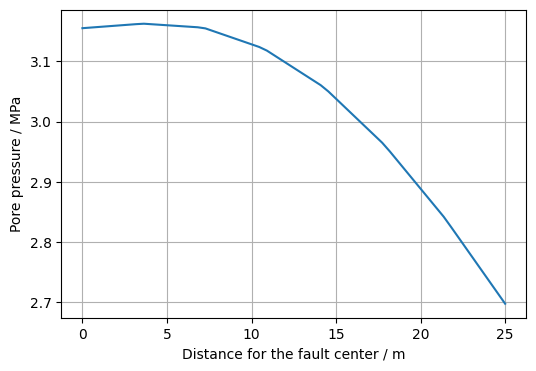

In [8]:
plt.rcParams["figure.figsize"] = [6, 4]
plt.plot(x_prf, profile["pressure"] * 1e-6, color="C0")
plt.ylabel(r"Pore pressure / MPa")
plt.xlabel("Distance for the fault center / m")
plt.grid(True)
plt.show()

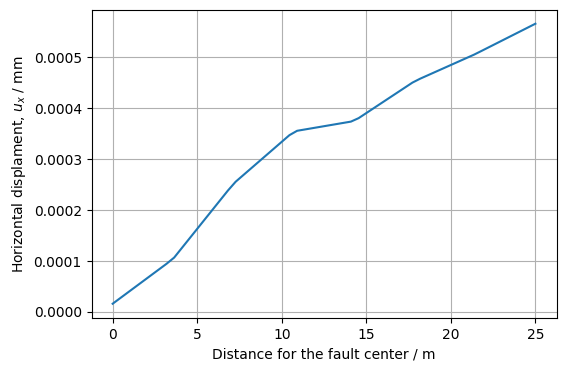

In [9]:
plt.rcParams["figure.figsize"] = [6, 4]
plt.plot(x_prf, profile["displacement"][:, 0] * 1e3, color="C0")
plt.ylabel(r"Horizontal displament, $u_{x}$ / mm")
plt.xlabel("Distance for the fault center / m")
plt.grid(True)
plt.show()

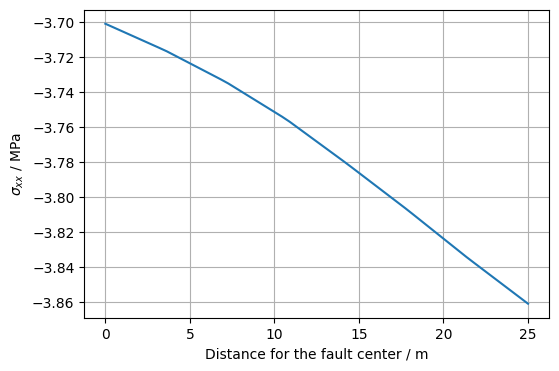

In [10]:
plt.rcParams["figure.figsize"] = [6, 4]
plt.plot(x_prf, profile["sigma"][:, 0] * 1e-6, color="C0")
plt.ylabel(r"$\sigma_{xx}$ / MPa")
plt.xlabel("Distance for the fault center / m")
plt.grid(True)
plt.show()

In [11]:
points = np.asarray([[0.0, 25.0, -300], [0.0, 25.0, -290]])

labels = ["Fault center", "10 m away"]

extracted_ms = ot.MeshSeries.extract_probe(ms, points)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 142/142 [00:01<00:00, 138.00it/s]


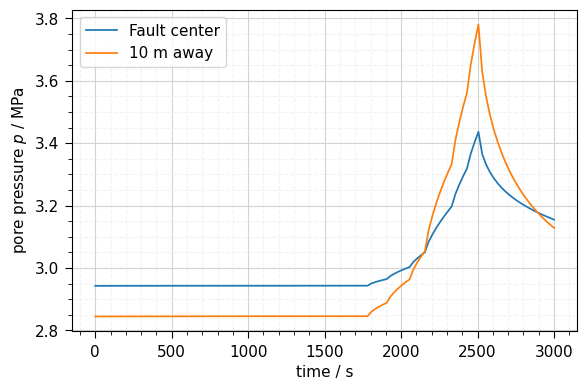

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ot.plot.line(
    extracted_ms,
    "time",
    ot.variables.pressure,
    labels=labels,
    ax=ax,
    loc="upper left",
    figsize=(6, 4),
    fontsize=11,
    linewidth=0.5,
)

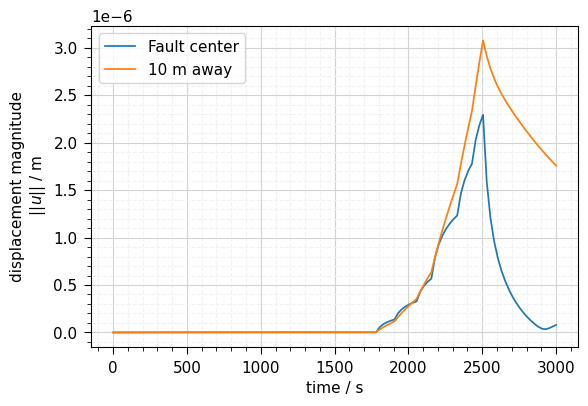

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

ot.plot.line(
    extracted_ms,
    "time",
    ot.variables.displacement,
    labels=labels,
    ax=ax,
    loc="upper left",
    figsize=(6, 4),
    fontsize=11,
    linewidth=0.5,
)

AttributeError: Line2D.set() got an unexpected keyword argument 'afigsize'

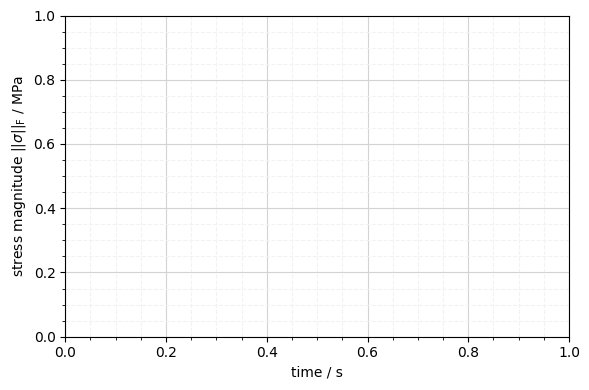

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

ot.plot.line(
    extracted_ms,
    "time",
    ot.variables.s,
    labels=labels,
    ax=ax,
    loc="upper left",
    figsize=(6, 4),
    fontsize=11,
    linewidth=0.5,
)

In [ ]:
pl = ot.plot.contourf_pv(
    ms[-1],
    ot.variables.pressure,
)
pl.show()

In [ ]:
pl = ot.plot.contourf_pv(
    ms[-1],
    ot.variables.stress,
)
pl.show()